Metropolitan Jam Penalty: 9.78 minutes
Urban Jam Penalty: 8.50 minutes


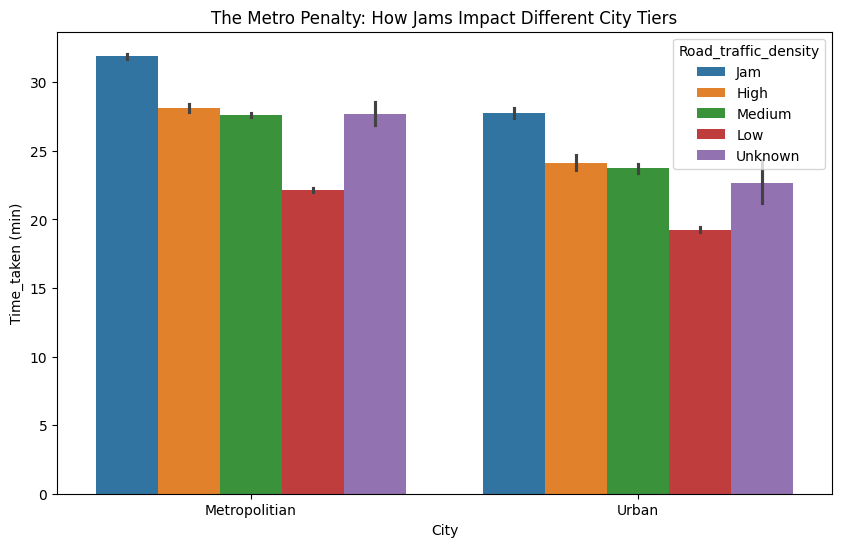

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Zomato_Delivery_Cleaned.csv')

# Calculate the 'Penalty' - Difference between Jam and Low traffic
metro_data = df[df['City'] == 'Metropolitian']
urban_data = df[df['City'] == 'Urban']

jam_metro = metro_data[metro_data['Road_traffic_density'] == 'Jam']['Time_taken (min)'].mean()
low_metro = metro_data[metro_data['Road_traffic_density'] == 'Low']['Time_taken (min)'].mean()

jam_urban = urban_data[urban_data['Road_traffic_density'] == 'Jam']['Time_taken (min)'].mean()
low_urban = urban_data[urban_data['Road_traffic_density'] == 'Low']['Time_taken (min)'].mean()

print(f"Metropolitan Jam Penalty: {jam_metro - low_metro:.2f} minutes")
print(f"Urban Jam Penalty: {jam_urban - low_urban:.2f} minutes")

# Visual Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='City', y='Time_taken (min)', hue='Road_traffic_density', data=df[df['City'].isin(['Urban', 'Metropolitian'])])
plt.title('The Metro Penalty: How Jams Impact Different City Tiers')
plt.show()

--- Quality of Service Audit ---
               Delivery_person_Ratings  Vehicle_condition
City                                                     
Metropolitian                 4.623283           1.004841
Urban                         4.667302           1.088523


C:\Users\sur3s\AppData\Local\Temp\ipykernel_15784\26090406.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City', y='Delivery_person_Ratings', data=df[df['City'].isin(['Urban', 'Metropolitian'])], palette='coolwarm')


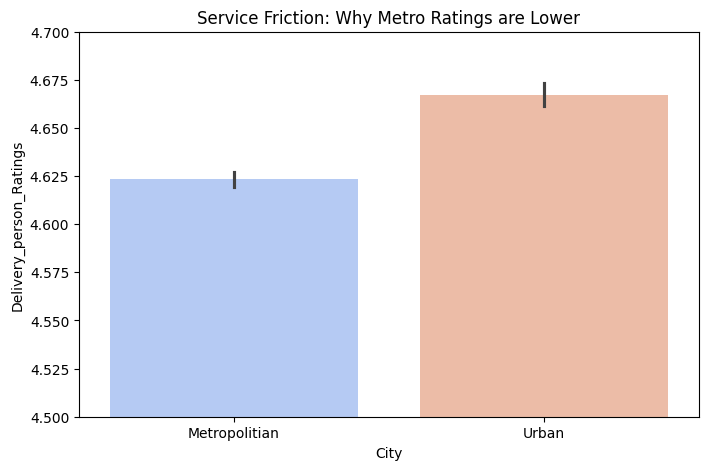

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Zomato_Delivery_Cleaned.csv')

# Compare Quality Metrics
quality_audit = df[df['City'].isin(['Urban', 'Metropolitian'])].groupby('City')[['Delivery_person_Ratings', 'Vehicle_condition']].mean()
print("--- Quality of Service Audit ---")
print(quality_audit)

# Visualization: Zoomed view of the Ratings Gap
plt.figure(figsize=(8, 5))
sns.barplot(x='City', y='Delivery_person_Ratings', data=df[df['City'].isin(['Urban', 'Metropolitian'])], palette='coolwarm')
plt.ylim(4.5, 4.7) 
plt.title('Service Friction: Why Metro Ratings are Lower')
plt.show()

In [3]:
import pandas as pd

df = pd.read_csv('Zomato_Delivery_Cleaned.csv')
df['City_Code'] = df['Delivery_person_ID'].str[:3]
north_codes = ['JAP', 'AGR', 'LUD', 'KNP', 'ALH', 'DEH', 'IND', 'BHP', 'RAN', 'KOL']
south_codes = ['BAN', 'HYD', 'MYS', 'COI', 'CHE', 'KOC']

# Frequency of Fog in North vs Storms in South
north_fog = (df[df['City_Code'].isin(north_codes)]['Weather_conditions'] == 'Fog').mean() * 100
south_storm = (df[df['City_Code'].isin(south_codes)]['Weather_conditions'] == 'Stormy').mean() * 100

# Impact on Time
fog_time = df[df['Weather_conditions'] == 'Fog']['Time_taken (min)'].mean()
storm_time = df[df['Weather_conditions'] == 'Stormy']['Time_taken (min)'].mean()

print(f"North India Fog Frequency: {north_fog:.2f}% (Avg Time: {fog_time:.2f}m)")
print(f"South India Storm Frequency: {south_storm:.2f}% (Avg Time: {storm_time:.2f}m)")

North India Fog Frequency: 16.95% (Avg Time: 28.91m)
South India Storm Frequency: 16.89% (Avg Time: 25.87m)


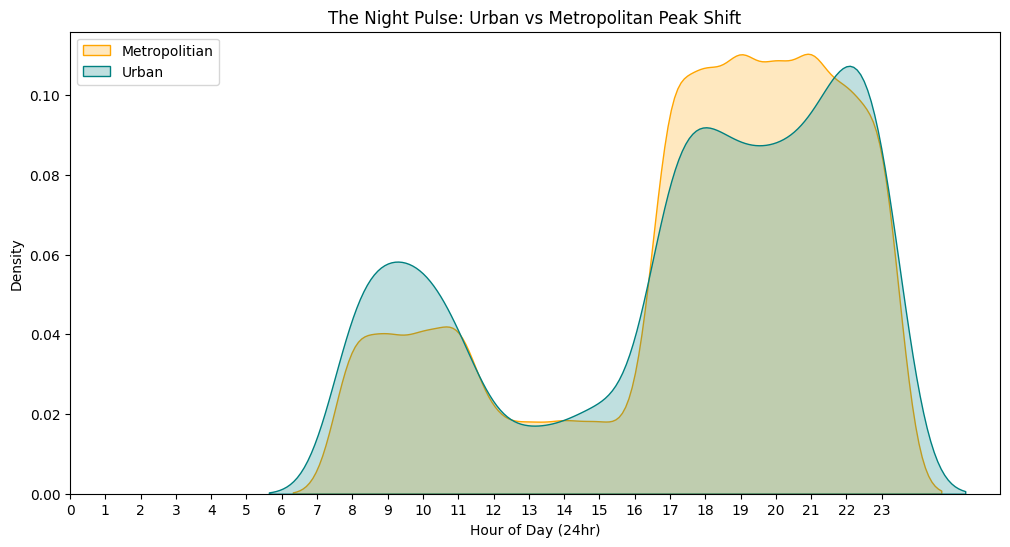

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Zomato_Delivery_Cleaned.csv')
# Extract Hour
df['Order_Hour'] = df['Time_Orderd'].apply(lambda x: int(str(x).split(':')[0]) if ':' in str(x) else None)
df = df.dropna(subset=['Order_Hour'])

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['City'] == 'Metropolitian'], x='Order_Hour', label='Metropolitian', fill=True, color='orange')
sns.kdeplot(data=df[df['City'] == 'Urban'], x='Order_Hour', label='Urban', fill=True, color='teal')
plt.xticks(range(0, 24))
plt.title('The Night Pulse: Urban vs Metropolitan Peak Shift')
plt.xlabel('Hour of Day (24hr)')
plt.legend()
plt.show()